In [23]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [24]:
from huggingface_hub import hf_hub_download
file = hf_hub_download(
    repo_id="AHFIDAILabs/immuniwatch",
    filename="all_tweets_with_labels.csv",
    repo_type="dataset"
)


In [25]:
import os

# Create all required directories (works on Windows and Linux)
dirs = [
    'data/monitoring',
    'data/splits', 
    'data/predictions',
    'data/labeled'
]

for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f"Ready: {d}")

print("\nAll directories ready")

Ready: data/monitoring
Ready: data/splits
Ready: data/predictions
Ready: data/labeled

All directories ready


In [26]:
df = pd.read_csv(file)

In [27]:
df.head()

,Tweet_Text,Reply_Count,Retweet_Count,Like_Count,View_Count,Language,Source,Username,Location,year,month,day,hour,minute,weekday,Post_ID,ID_Source,predicted_label
0,The HPV vaccine is a critical step in preventi...,1.0,0.0,2.0,81.0,English,Twitter,VaccineNet_NG,"Lagos, Nigeria",2024,7,1,17,58,Monday,"=""1807821100576895401""",Platform_ID,Factual
1,"New month, new experiences, new opportunities,...",0.0,0.0,2.0,50.0,English,Twitter,VaccineNet_NG,Abuja. Nigeria.,2024,7,1,15,2,Monday,"=""1807776904805580853""",Platform_ID,NaN
2,Blessing is protected against cervical cancer....,0.0,1.0,6.0,137.0,English,Twitter,VaccineNet_NG,Lagos,2024,6,27,14,27,Thursday,"=""1806318372742635560""",Platform_ID,Factual
3,https://t.co/wirqlPgG1q,0.0,0.0,4.0,46.0,German,Twitter,VaccineNet_NG,Well informed,2024,6,27,14,27,Thursday,"=""1806318348721954865""",Platform_ID,NaN
4,@science_nigeria @nighealthwatch @Fmohnigeria ...,0.0,0.0,0.0,5.0,English,Twitter,VaccineNet_NG,Nigeria,2024,6,25,11,8,Tuesday,"=""1805543612580606082""",Platform_ID,Factual


In [28]:
df.isnull().sum()

Tweet_Text             0
Reply_Count            0
Retweet_Count          0
Like_Count             0
View_Count             0
Language               0
Source                 0
Username               0
Location               0
year                   0
month                  0
day                    0
hour                   0
minute                 0
weekday                0
Post_ID                0
ID_Source              0
predicted_label    33334
dtype: int64

In [29]:
#making a copy of the dataframe to work with
df_copy = df.copy()

In [30]:
df.shape    

(45005, 18)

In [31]:
df.columns

Index(['Tweet_Text', 'Reply_Count', 'Retweet_Count', 'Like_Count',
       'View_Count', 'Language', 'Source', 'Username', 'Location', 'year',
       'month', 'day', 'hour', 'minute', 'weekday', 'Post_ID', 'ID_Source',
       'predicted_label'],
      dtype='object')

In [32]:
print("=== DATASET OVERVIEW ===")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== DATASET OVERVIEW ===
Total rows: 45,005
Total columns: 18

Data types:
Tweet_Text          object
Reply_Count        float64
Retweet_Count      float64
Like_Count         float64
View_Count         float64
Language            object
Source              object
Username            object
Location            object
year                 int64
month                int64
day                  int64
hour                 int64
minute               int64
weekday             object
Post_ID             object
ID_Source           object
predicted_label     object
dtype: object

Memory usage: 34.57 MB


In [33]:
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

=== MISSING VALUES ===
                 Missing Count  Missing %
predicted_label          33334      74.07


=== LABEL DISTRIBUTION ===
                 Count  Percentage
predicted_label                   
NaN              33334       74.07
Uncertain         6464       14.36
Factual           4489        9.97
Misinformation     718        1.60


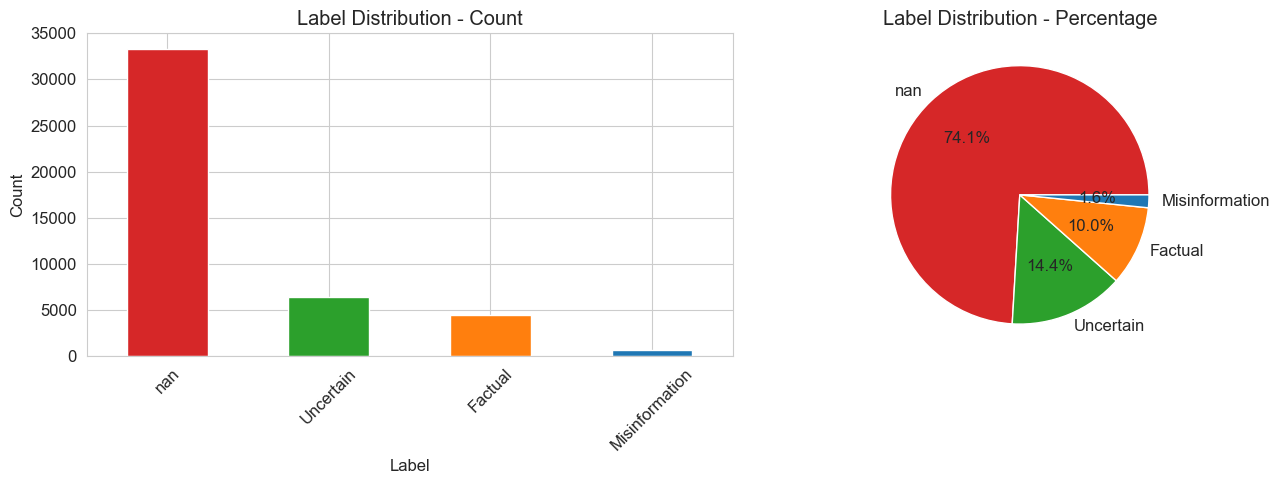

Saved: data/monitoring/label_distribution.png


In [34]:
print("=== LABEL DISTRIBUTION ===")
label_counts = df['predicted_label'].value_counts(dropna=False)
label_pct = df['predicted_label'].value_counts(dropna=False, normalize=True) * 100

label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_pct.round(2)
})
print(label_summary)
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts.plot(kind='bar', ax=axes[0], color=['#d62728','#2ca02c','#ff7f0e','#1f77b4'])
axes[0].set_title('Label Distribution - Count')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

label_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
               colors=['#d62728','#2ca02c','#ff7f0e','#1f77b4'])
axes[1].set_title('Label Distribution - Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/monitoring/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/label_distribution.png")


In [35]:
import os
print(os.getcwd())

c:\Users\USER\Desktop\immuniwatch_project\notebooks


In [39]:
print("=== CLASS IMBALANCE ANALYSIS ===")
labeled = df[df['predicted_label'].notna()]
unlabeled = df[df['predicted_label'].isna()]

print(f"Labeled rows:   {len(labeled):,}")
print(f"Unlabeled rows: {len(unlabeled):,}")

counts = labeled['predicted_label'].value_counts()
ratio = counts.max() / counts.min()

print(f"\nImbalance ratio: {ratio:.1f}x")
print(f"Majority class:  {counts.idxmax()} ({counts.max():,})")
print(f"Minority class:  {counts.idxmin()} ({counts.min():,})")
#print(f"\nAction required: class weights + back-translation augmentation on minority class")

=== CLASS IMBALANCE ANALYSIS ===
Labeled rows:   11,671
Unlabeled rows: 33,334

Imbalance ratio: 9.0x
Majority class:  Uncertain (6,464)
Minority class:  Misinformation (718)


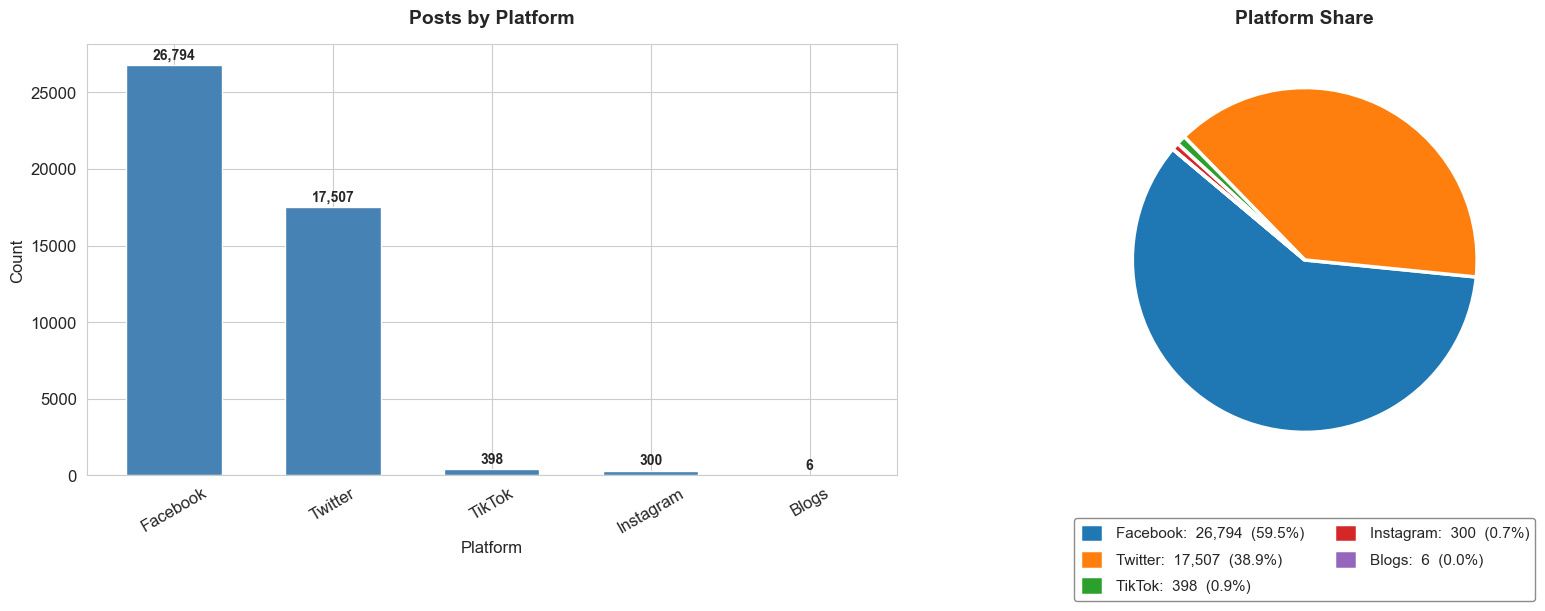

Saved: data/monitoring/platform_distribution.png


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

source_counts = df['Source'].value_counts()

# Bar chart with count labels
bars = source_counts.plot(kind='bar', ax=axes[0], color='steelblue', width=0.6)
axes[0].set_title('Posts by Platform', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Platform', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Pie chart - NO labels or percentages on the chart itself
# Everything goes into a clean external legend
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
wedges, texts = axes[1].pie(
    source_counts,
    labels=None,
    autopct=None,
    startangle=140,
    colors=colors[:len(source_counts)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}
)
axes[1].set_title('Platform Share', fontsize=14, fontweight='bold', pad=15)

# Build clean legend with platform name + count + percentage
total = source_counts.sum()
legend_labels = [
    f'{label}:  {count:,}  ({count/total*100:.1f}%)'
    for label, count in zip(source_counts.index, source_counts)
]

axes[1].legend(
    wedges,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor='grey',
    handlelength=1.5,
    handleheight=1.5
)

plt.tight_layout(pad=3.0)
plt.savefig('data/monitoring/platform_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/platform_distribution.png")

In [43]:
print("=== LABEL BY PLATFORM ===")
platform_label = df.groupby(
    ['Source', 'predicted_label']
).size().unstack(fill_value=0)
print(platform_label)

=== LABEL BY PLATFORM ===
predicted_label  Factual  Misinformation  Uncertain
Source                                             
Blogs                  6               0          0
Facebook            1699             320       3699
Instagram             10               0          4
TikTok                 5               0          2
Twitter             2769             398       2759


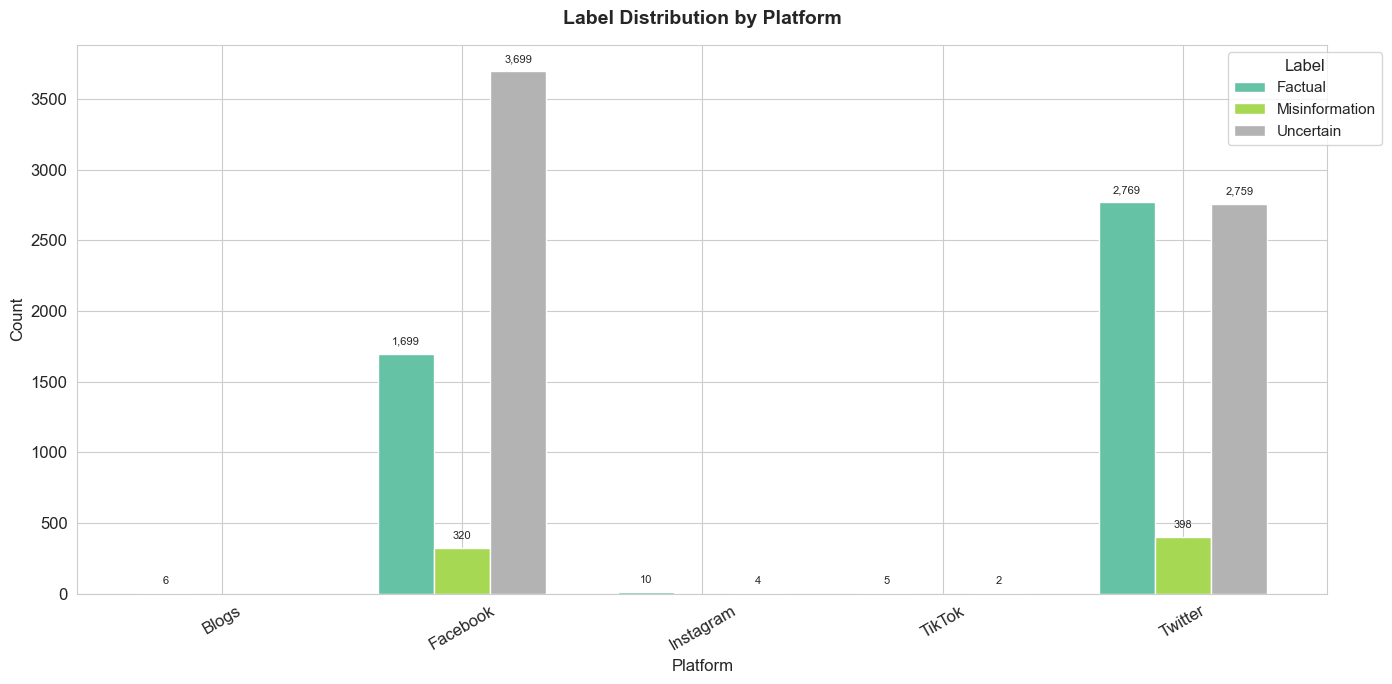

Saved: data/monitoring/label_by_platform.png


In [44]:
ax = platform_label.plot(kind='bar', figsize=(14, 7), colormap='Set2', width=0.7)
plt.title('Label Distribution by Platform', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tick_params(axis='x', rotation=30)
plt.legend(title='Label', bbox_to_anchor=(1.05, 1), fontsize=11)

for bar in ax.patches:
    if bar.get_height() > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.savefig('data/monitoring/label_by_platform.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/label_by_platform.png")

In [45]:
print("=== LANGUAGE DISTRIBUTION ===")
print(df['Language'].value_counts())

=== LANGUAGE DISTRIBUTION ===
Language
English      35947
Igbo          2357
French         675
Chinese        534
Yoruba         485
             ...  
Irish            2
Malagasy         2
Gujarati         2
Ukrainian        2
Faroese          2
Name: count, Length: 89, dtype: int64


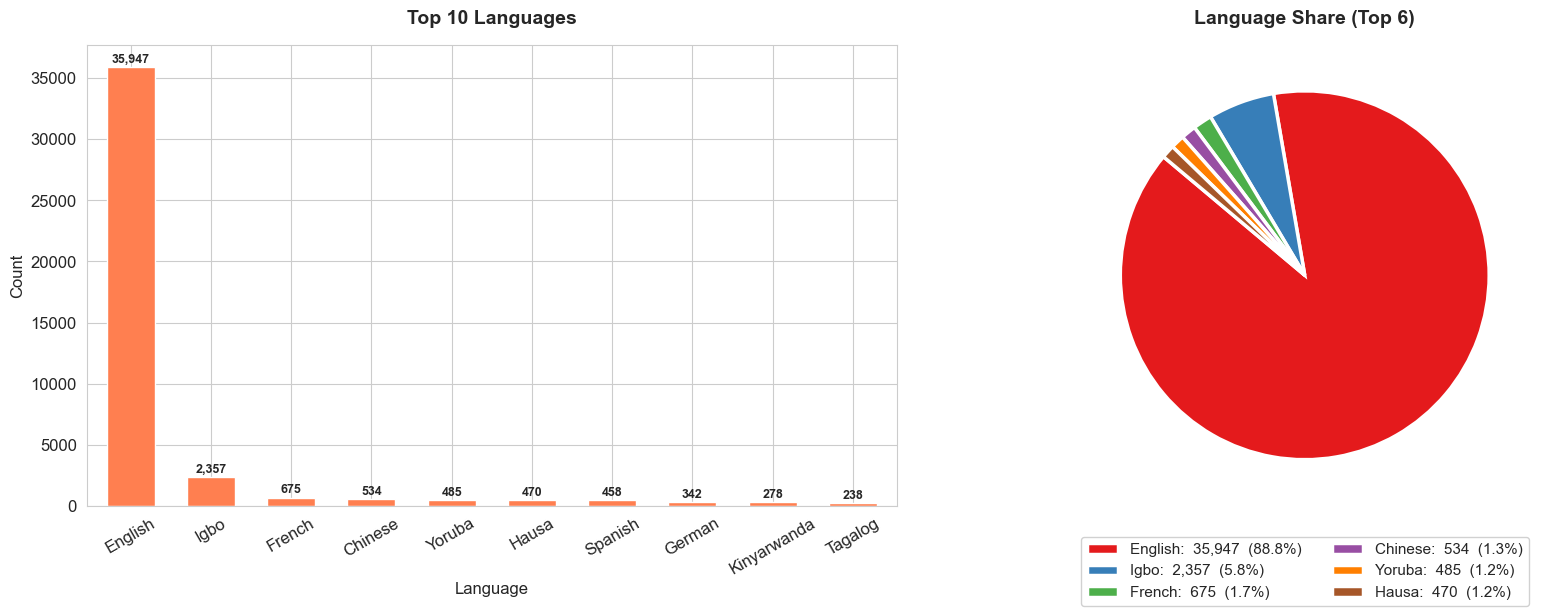

Saved: data/monitoring/language_distribution.png


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

lang_counts = df['Language'].value_counts()

# Bar chart top 10
lang_counts.head(10).plot(kind='bar', ax=axes[0], color='coral', width=0.6)
axes[0].set_title('Top 10 Languages', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Language', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# Pie chart top 6 - legend only
top6 = lang_counts.head(6)
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']
wedges, texts = axes[1].pie(
    top6,
    labels=None,
    autopct=None,
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}
)
axes[1].set_title('Language Share (Top 6)', fontsize=14, fontweight='bold', pad=15)
total = top6.sum()
legend_labels = [
    f'{label}:  {count:,}  ({count/total*100:.1f}%)'
    for label, count in zip(top6.index, top6)
]
axes[1].legend(
    wedges, legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=2, fontsize=11,
    frameon=True, framealpha=0.9
)

plt.tight_layout(pad=3.0)
plt.savefig('data/monitoring/language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/language_distribution.png")

In [47]:
print("=== LABEL BY LANGUAGE ===")
top_langs = df['Language'].value_counts().head(6).index
lang_label = df[df['Language'].isin(top_langs)].groupby(
    ['Language', 'predicted_label']
).size().unstack(fill_value=0)
print(lang_label)

=== LABEL BY LANGUAGE ===
predicted_label  Factual  Misinformation  Uncertain
Language                                           
Chinese                2               0          2
English             3856             656       5500
French                12               6        122
Hausa                  6               4         76
Igbo                 525              46        548
Yoruba                22               0         32


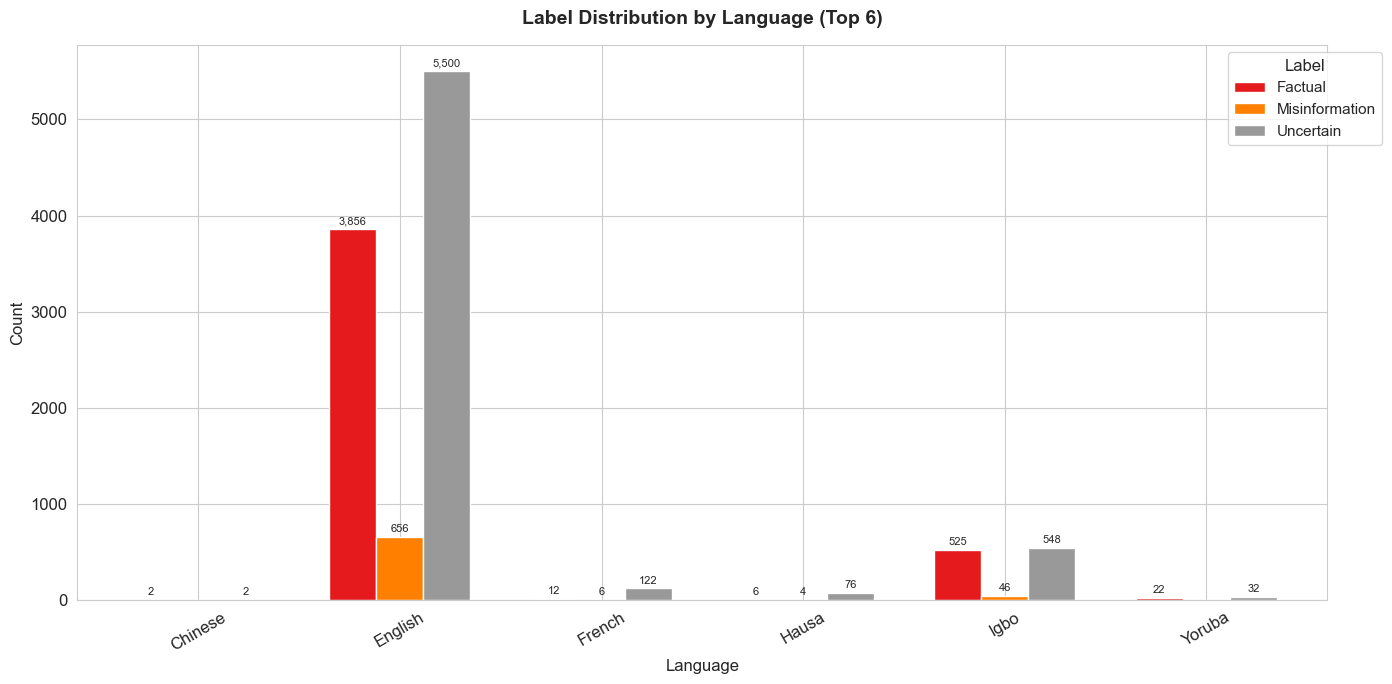

Saved: data/monitoring/label_by_language.png


In [48]:
ax = lang_label.plot(kind='bar', figsize=(14, 7), colormap='Set1', width=0.7)
plt.title('Label Distribution by Language (Top 6)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Language', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tick_params(axis='x', rotation=30)
plt.legend(title='Label', bbox_to_anchor=(1.05, 1), fontsize=11)

for bar in ax.patches:
    if bar.get_height() > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.savefig('data/monitoring/label_by_language.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/label_by_language.png")

In [49]:
print("=== TEMPORAL OVERVIEW ===")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")
print(f"\nPosts per year:")
print(df['year'].value_counts().sort_index())
print(f"\nPosts per month:")
print(df['month'].value_counts().sort_index())

=== TEMPORAL OVERVIEW ===
Year range: 2008 to 2025

Posts per year:
year
2008        1
2009        7
2010       11
2011       34
2012       25
2013       34
2014       18
2015       40
2016       23
2017       16
2018       18
2019      236
2020       31
2021     5317
2022      491
2023     3818
2024    18303
2025    16582
Name: count, dtype: int64

Posts per month:
month
1      1254
2      2285
3      3099
4      5398
5      1459
6      3871
7      2258
8      3065
9      3091
10     4191
11    11436
12     3598
Name: count, dtype: int64


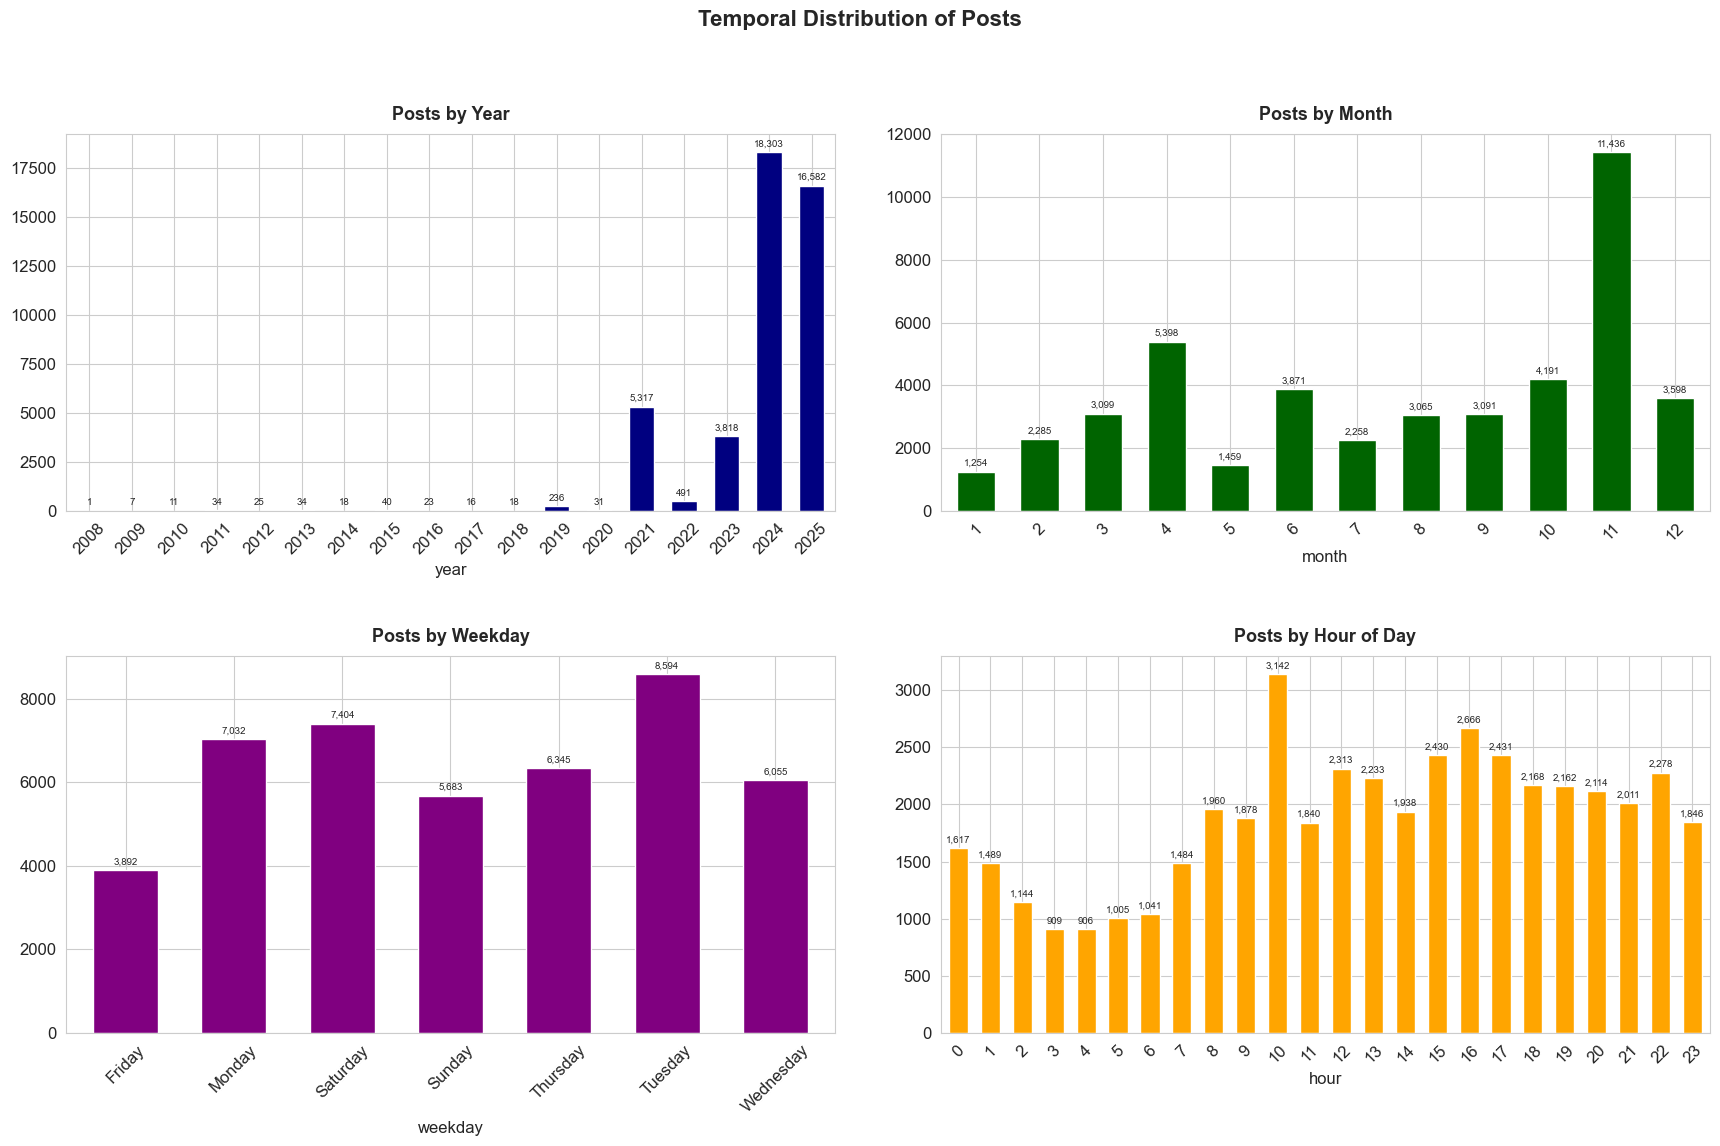

Saved: data/monitoring/temporal_distribution.png


In [50]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

datasets = [
    (df['year'].value_counts().sort_index(), 'Posts by Year', 'navy'),
    (df['month'].value_counts().sort_index(), 'Posts by Month', 'darkgreen'),
    (df['weekday'].value_counts().sort_index(), 'Posts by Weekday', 'purple'),
    (df['hour'].value_counts().sort_index(), 'Posts by Hour of Day', 'orange'),
]

for idx, (data, title, color) in enumerate(datasets):
    ax = axes[idx//2, idx%2]
    data.plot(kind='bar', ax=ax, color=color, width=0.6)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(axis='x', rotation=45)
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + data.max() * 0.01,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=7
        )

plt.suptitle('Temporal Distribution of Posts', fontsize=16, fontweight='bold')
plt.tight_layout(pad=3.0)
plt.savefig('data/monitoring/temporal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/temporal_distribution.png")

In [51]:
print("=== MISINFORMATION TREND OVER TIME ===")
labeled = df[df['predicted_label'].notna()].copy()
labeled['year_month'] = (
    labeled['year'].astype(str) + '-' +
    labeled['month'].astype(str).str.zfill(2)
)
trend = labeled.groupby(
    ['year_month', 'predicted_label']
).size().unstack(fill_value=0)
print(trend.tail(10))

=== MISINFORMATION TREND OVER TIME ===
predicted_label  Factual  Misinformation  Uncertain
year_month                                         
2025-02              517              10         96
2025-03               37              10        102
2025-04               15               0         36
2025-05                3               0         10
2025-06              129              30        238
2025-07               26               7         68
2025-08              117              16        199
2025-09               18               4         69
2025-10              122              24        270
2025-11              521             114       1146


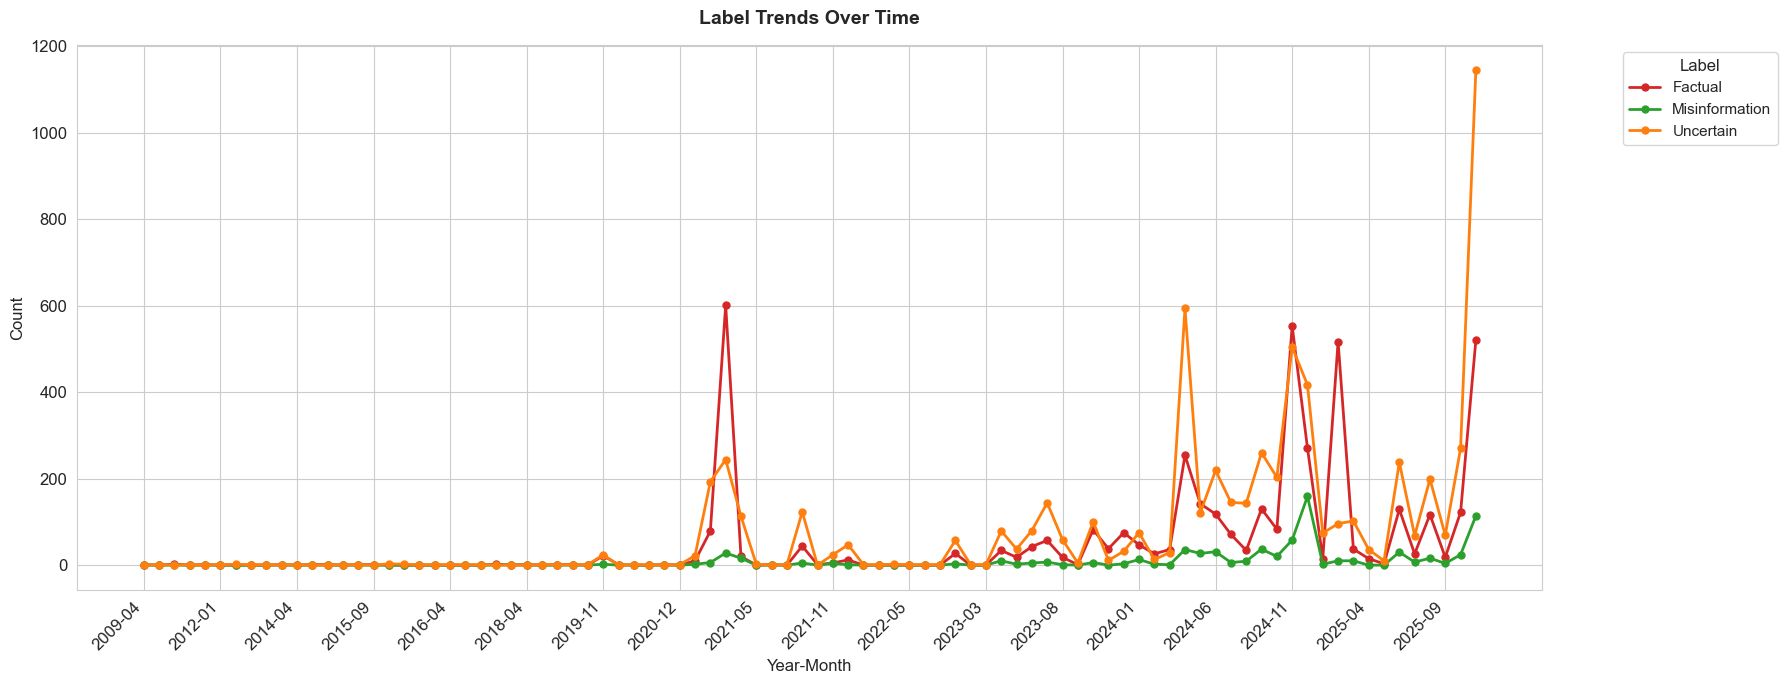

Saved: data/monitoring/misinformation_trend.png


In [52]:
fig, ax = plt.subplots(figsize=(18, 7))

colors = ['#d62728', '#2ca02c', '#ff7f0e']
for i, col in enumerate(trend.columns):
    ax.plot(trend.index, trend[col],
            marker='o', linewidth=2,
            markersize=5, label=col,
            color=colors[i % len(colors)])

ax.set_title('Label Trends Over Time', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year-Month', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Label', fontsize=11, bbox_to_anchor=(1.05, 1))

# Show every 3rd x label to avoid overlap
tick_positions = range(0, len(trend.index), max(1, len(trend.index)//15))
ax.set_xticks([list(trend.index)[i] for i in tick_positions])
ax.set_xticklabels([list(trend.index)[i] for i in tick_positions], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('data/monitoring/misinformation_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/misinformation_trend.png")

In [53]:
print("=== ENGAGEMENT METRICS ===")
engagement_cols = ['Reply_Count', 'Retweet_Count', 'Like_Count', 'View_Count']
print(df[engagement_cols].describe().round(2))

=== ENGAGEMENT METRICS ===
       Reply_Count  Retweet_Count  Like_Count   View_Count
count     45005.00       45005.00    45005.00     45005.00
mean          0.47           1.59       10.27      6464.45
std           8.27          34.18      165.68    261353.03
min           0.00           0.00        0.00         0.00
25%           0.00           0.00        1.00        81.00
50%           0.00           0.00        1.00        81.00
75%           0.00           0.00        1.00        81.00
max         725.00        2507.00     9249.00  23410141.00


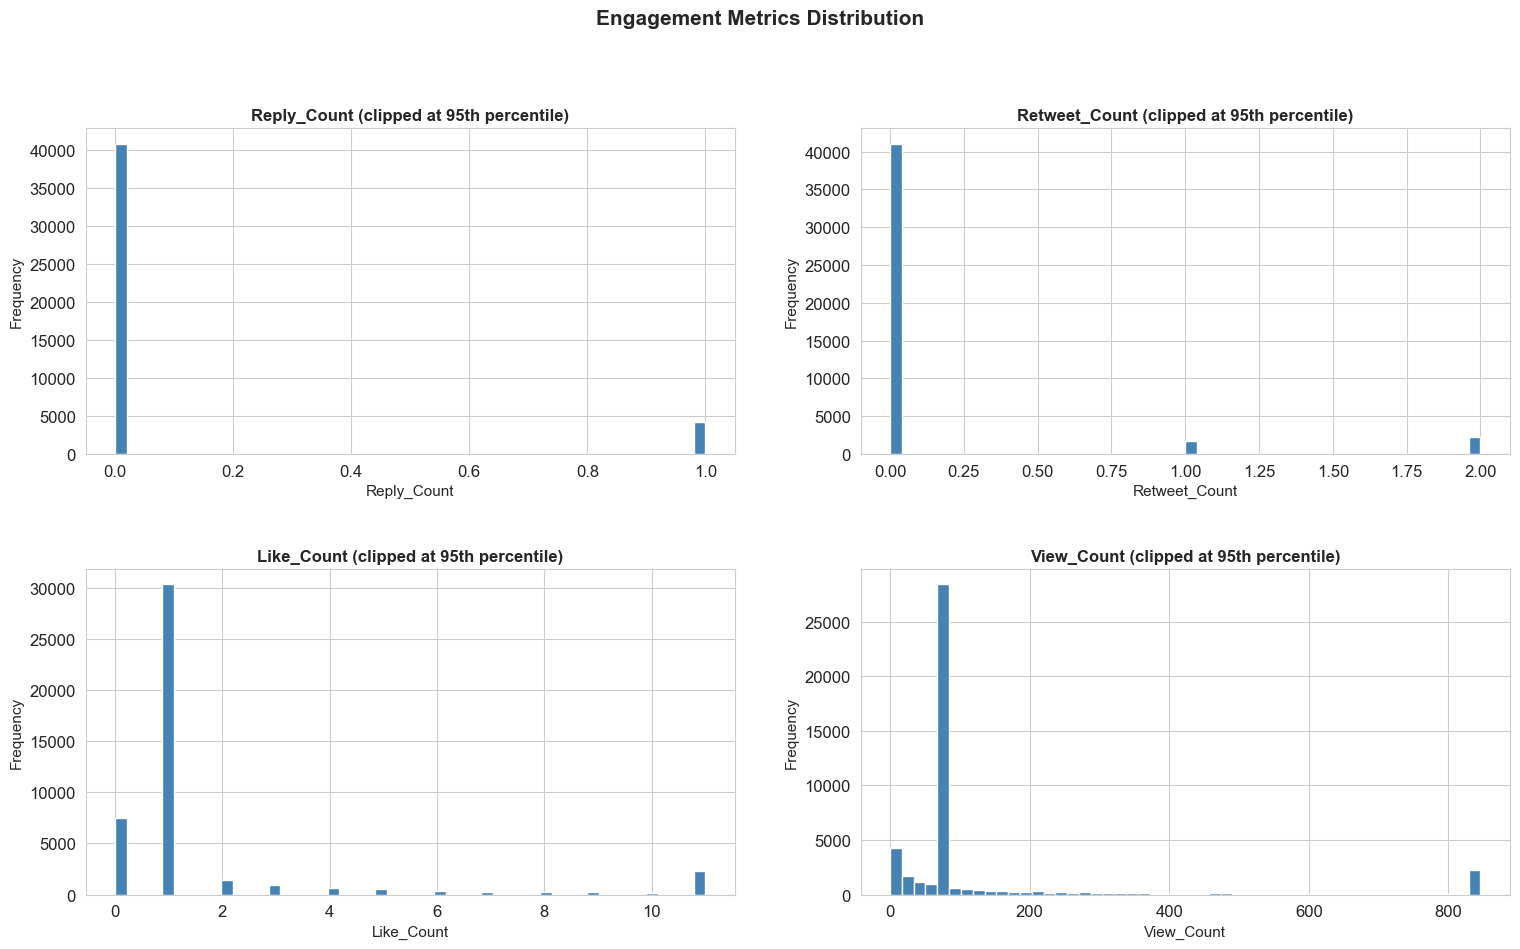

Saved: data/monitoring/engagement_distribution.png


In [54]:
engagement_cols = ['Reply_Count', 'Retweet_Count', 'Like_Count', 'View_Count']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, col in enumerate(engagement_cols):
    ax = axes[i//2, i%2]
    clip_val = df[col].quantile(0.95)
    df[col].clip(upper=clip_val).plot(
        kind='hist', bins=50, ax=ax,
        color='steelblue', edgecolor='white')
    ax.set_title(f'{col} (clipped at 95th percentile)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)

plt.suptitle('Engagement Metrics Distribution', fontsize=15, fontweight='bold')
plt.tight_layout(pad=3.0)
plt.savefig('data/monitoring/engagement_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/engagement_distribution.png")

In [55]:
print("=== MEDIAN ENGAGEMENT BY LABEL ===")
labeled = df[df['predicted_label'].notna()]
print(labeled.groupby('predicted_label')[engagement_cols].median().round(2))

=== MEDIAN ENGAGEMENT BY LABEL ===
                 Reply_Count  Retweet_Count  Like_Count  View_Count
predicted_label                                                    
Factual                  0.0            0.0         1.0        81.0
Misinformation           0.0            0.0         1.0        81.0
Uncertain                0.0            0.0         1.0        81.0


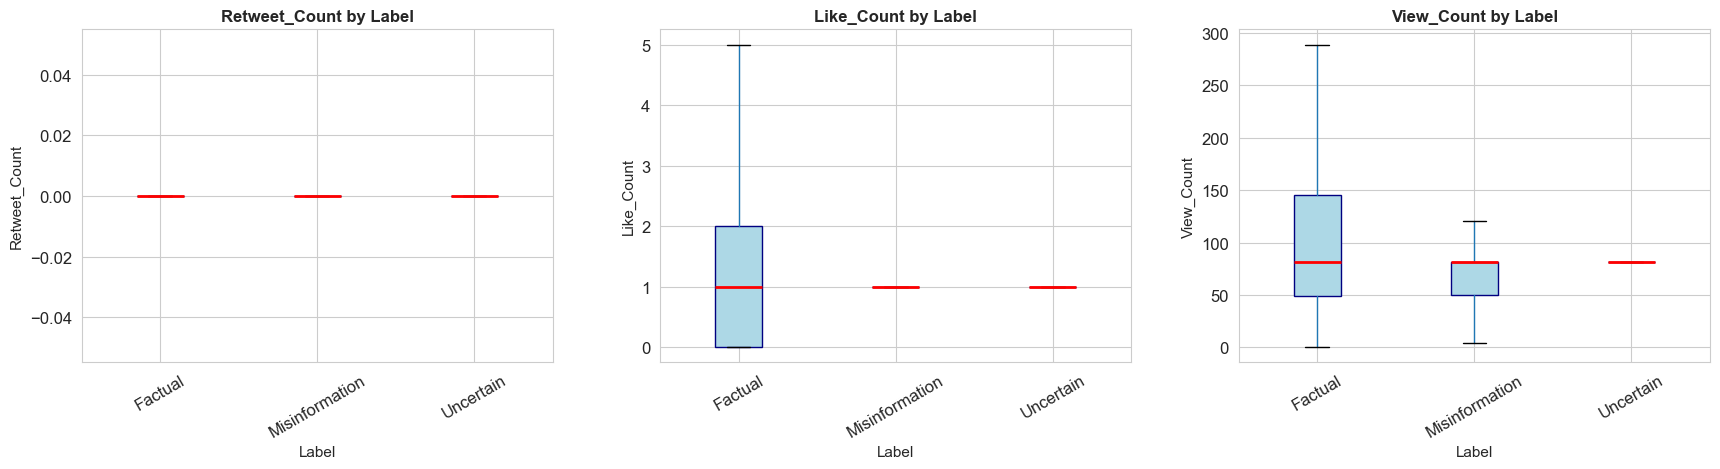

Saved: data/monitoring/engagement_by_label.png


In [56]:
labeled = df[df['predicted_label'].notna()]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(['Retweet_Count', 'Like_Count', 'View_Count']):
    labeled.boxplot(
        column=col, by='predicted_label',
        ax=axes[i], showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[i].set_title(f'{col} by Label', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Label', fontsize=11)
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('', fontsize=1)
plt.tight_layout(pad=3.0)
plt.savefig('data/monitoring/engagement_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/engagement_by_label.png")

In [57]:
print("=== TEXT LENGTH ANALYSIS ===")
df['text_length'] = df['Tweet_Text'].astype(str).apply(len)
df['word_count'] = df['Tweet_Text'].astype(str).apply(lambda x: len(x.split()))

print(df[['text_length', 'word_count']].describe().round(2))

labeled = df[df['predicted_label'].notna()]
print("\nAverage text length by label:")
print(labeled.groupby('predicted_label')[['text_length', 'word_count']].mean().round(2))

=== TEXT LENGTH ANALYSIS ===
       text_length  word_count
count     45005.00    45005.00
mean        120.06       16.94
std         229.08       33.48
min           1.00        1.00
25%          28.00        4.00
50%          60.00        9.00
75%         139.00       20.00
max        8374.00     1234.00

Average text length by label:
                 text_length  word_count
predicted_label                         
Factual               260.68       40.35
Misinformation        210.13       33.09
Uncertain             145.88       23.87


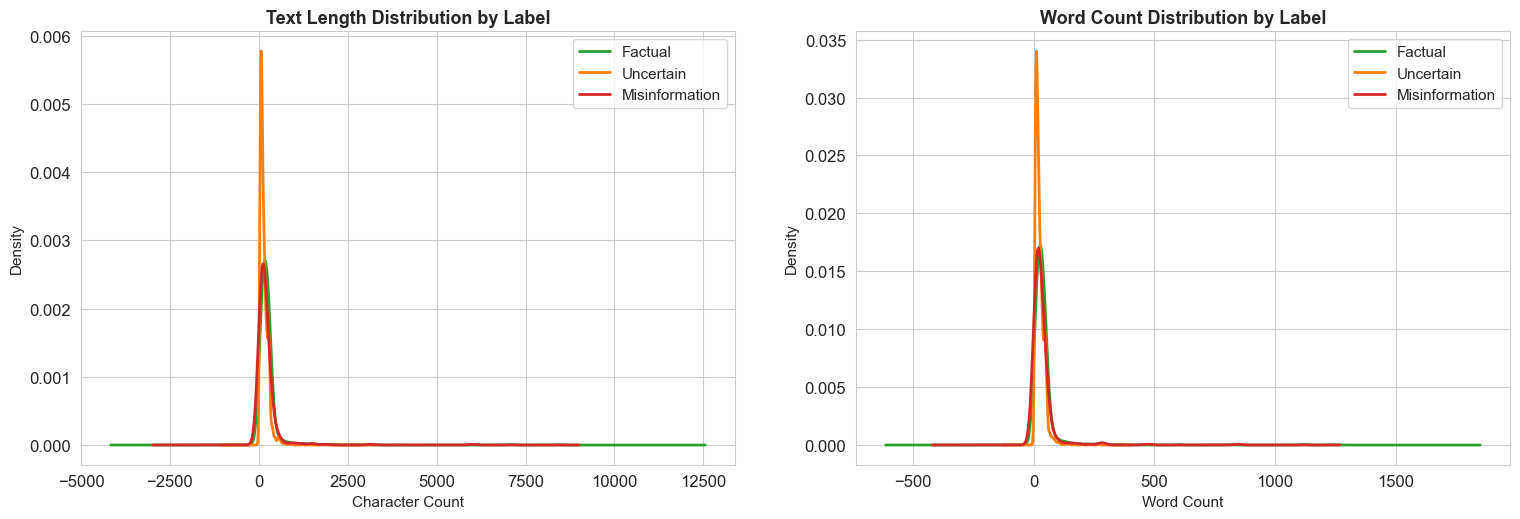

Saved: data/monitoring/text_length_by_label.png


In [ ]:
labeled = df[df['predicted_label'].notna()]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'Misinformation': '#d62728', 'Factual': '#2ca02c', 'Uncertain':'#ff7f0e',}

for label in labeled['predicted_label'].unique():
    subset = labeled[labeled['predicted_label'] == label]
    color = colors.get(label, 'steelblue')
    subset['text_length'].plot(
        kind='kde', ax=axes[0], label=label,
        linewidth=2, color=color)

axes[0].set_title('Text Length Distribution by Label',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend(fontsize=11)

for label in labeled['predicted_label'].unique():
    subset = labeled[labeled['predicted_label'] == label]
    color = colors.get(label, 'steelblue')
    subset['word_count'].plot(
        kind='kde', ax=axes[1], label=label,
        linewidth=2, color=color)

axes[1].set_title('Word Count Distribution by Label',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(fontsize=11)

plt.tight_layout(pad=3.0)
plt.savefig('data/monitoring/text_length_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/text_length_by_label.png")

=== TOP 20 LOCATIONS ===
Location
Nigeria                           4917
Lagos, Nigeria                    3793
Abuja, Nigeria                    2123
United States                      748
Canada                             413
USA                                405
Florida, USA                       394
Lagos                              348
Earth                              342
Enugu, Nigeria                     282
Lagos Nigeria                      240
Federal Capital Territory, Nig     206
India                              205
Ilorin, Nigeria                    202
Lagos, Nigeria.                    187
London, England                    185
DC via Abuja                       183
Global                             179
United Kingdom                     172
Australia                          167
Name: count, dtype: int64


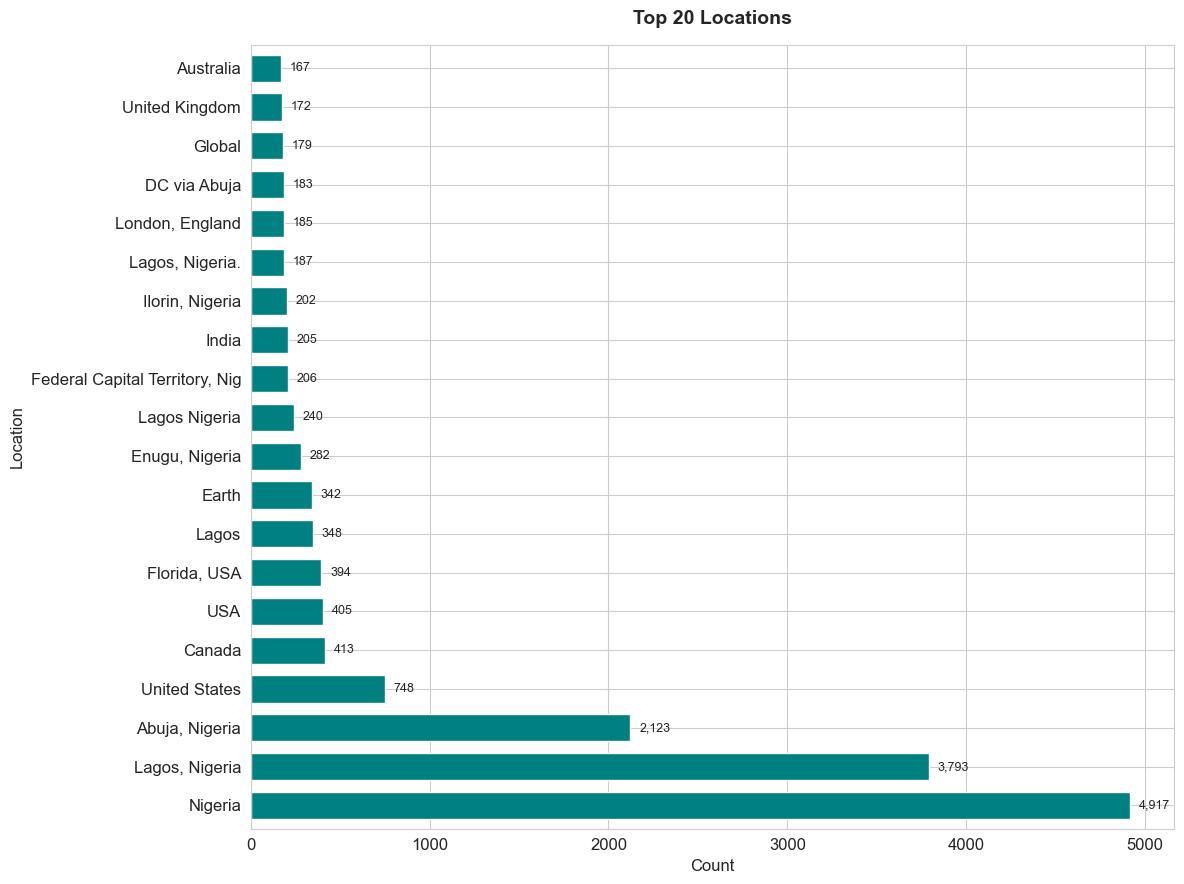

Saved: data/monitoring/location_distribution.png


In [59]:
print("=== TOP 20 LOCATIONS ===")
loc_counts = df['Location'].value_counts().head(20)
print(loc_counts)

fig, ax = plt.subplots(figsize=(12, 9))
loc_counts.plot(kind='barh', ax=ax, color='teal', width=0.7)
ax.set_title('Top 20 Locations', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Location', fontsize=12)

for bar in ax.patches:
    ax.text(
        bar.get_width() + loc_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width()):,}',
        va='center', fontsize=9
    )

plt.tight_layout()
plt.savefig('data/monitoring/location_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/location_distribution.png")